<a href="https://colab.research.google.com/github/asit18/ai-ml/blob/main/colab_activity6_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Self-study Colab Activity 6.2: Interpreting the Results of K-Means and PCA




In this activity, you are tasked with profiling customer groups for a large telecommunications company.  The data provided contains information on customers' purchasing and usage behavior with telecom products.  Your goal is to use PCA and clustering to segment these customers into meaningful groups, and report back your findings.  

Because these results need to be interpretable, it is important to keep the number of clusters reasonable.  Think about how you might represent some of the non-numeric features so that they can be included in your segmentation models.  You are to report back your approach and findings to the class.  Be specific about what features were used and how you interpret the resulting clusters.

In [220]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [221]:
df = pd.read_csv('sample_data/telco_churn_data.csv')

In [222]:
df.head()

,Customer ID,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,...,Latitude,Longitude,Population,Churn Value,CLTV,Churn Category,Churn Reason,Total Customer Svc Requests,Product/Service Issues Reported,Customer Satisfaction
0,8779-QRDMV,No,0,1,NaN,No,0.00,No,Yes,Fiber Optic,...,34.023810,-118.156582,68701,1,5433,Competitor,Competitor offered more data,5,0,NaN
1,7495-OOKFY,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,Cable,...,34.044271,-118.185237,55668,1,5302,Competitor,Competitor made better offer,5,0,NaN
2,1658-BYGOY,No,0,18,Offer D,Yes,11.33,Yes,Yes,Fiber Optic,...,34.108833,-118.229715,47534,1,3179,Competitor,Competitor made better offer,1,0,NaN
3,4598-XLKNJ,Yes,1,25,Offer C,Yes,19.76,No,Yes,Fiber Optic,...,33.936291,-118.332639,27778,1,5337,Dissatisfaction,Limited range of services,1,1,2.0
4,4846-WHAFZ,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,Cable,...,33.972119,-118.020188,26265,1,2793,Price,Extra data charges,1,0,2.0


In [223]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 46 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Referred a Friend                  7043 non-null   object 
 2   Number of Referrals                7043 non-null   int64  
 3   Tenure in Months                   7043 non-null   int64  
 4   Offer                              3166 non-null   object 
 5   Phone Service                      7043 non-null   object 
 6   Avg Monthly Long Distance Charges  7043 non-null   float64
 7   Multiple Lines                     7043 non-null   object 
 8   Internet Service                   7043 non-null   object 
 9   Internet Type                      5517 non-null   object 
 10  Avg Monthly GB Download            7043 non-null   int64  
 11  Online Security                    7043 non-null   objec

In [224]:
numeric_cols = df.select_dtypes(include=['number']).columns
zero_variance = [col for col in numeric_cols if df[col].var() == 0]
print(zero_variance)

categorical_cols = df.select_dtypes(include=['object', 'category']).columns
skewed_categorical = [col for col in categorical_cols if df[col].value_counts(normalize=True).iloc[0] > 0.98]

print(skewed_categorical)

unique_churn_values = df['Churn Value'].unique()
print(f"Unique values in 'Churn Value': {unique_churn_values}")

# df = df[df["Churn Value"] == 1]
df = df.drop(columns=['Customer ID','Offer'])
print(df.info())
print(df[["Streaming Movies","Streaming Music"]].nunique())

[]
[]
Unique values in 'Churn Value': [1 0]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 44 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Referred a Friend                  7043 non-null   object 
 1   Number of Referrals                7043 non-null   int64  
 2   Tenure in Months                   7043 non-null   int64  
 3   Phone Service                      7043 non-null   object 
 4   Avg Monthly Long Distance Charges  7043 non-null   float64
 5   Multiple Lines                     7043 non-null   object 
 6   Internet Service                   7043 non-null   object 
 7   Internet Type                      5517 non-null   object 
 8   Avg Monthly GB Download            7043 non-null   int64  
 9   Online Security                    7043 non-null   object 
 10  Online Backup                      7043 non-null   object 
 11  Device Prote

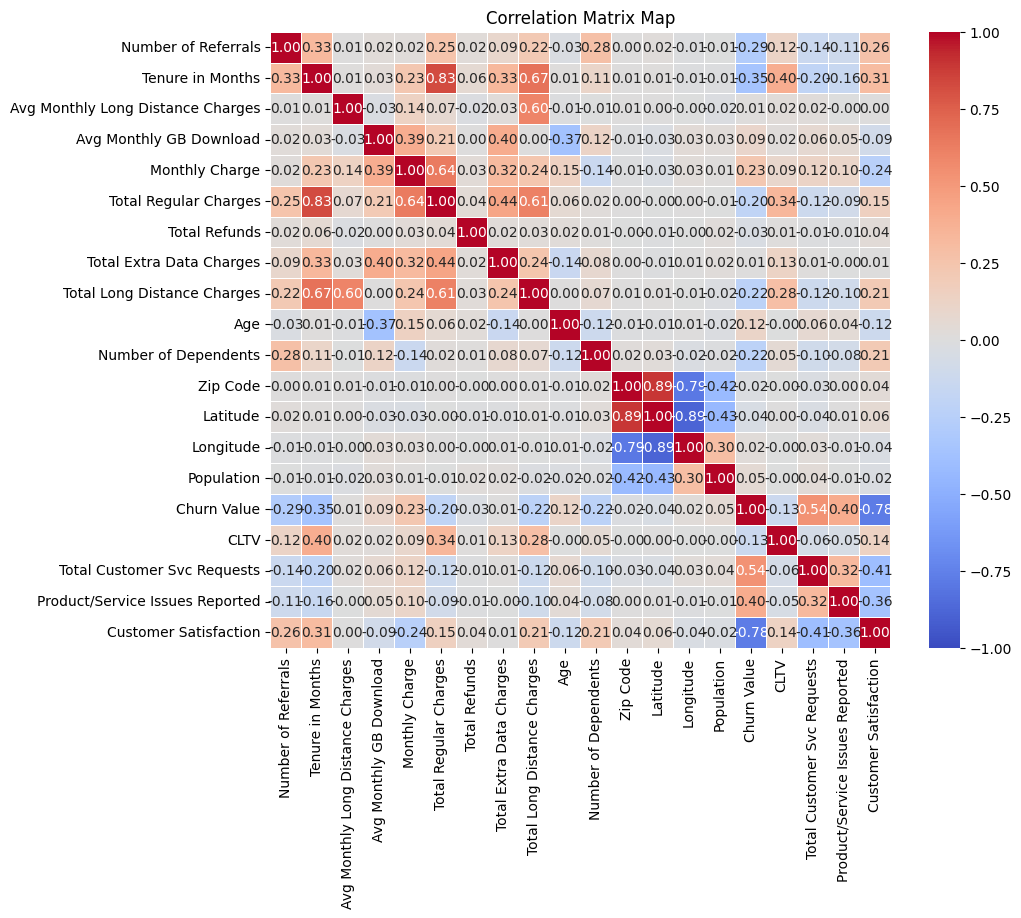

In [240]:
df["Churn Value" == 1]
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,  # Shows the correlation numbers inside the squares
    cmap="coolwarm",  # Red for positive correlation, blue for negative
    fmt=".2f",  # Limits decimals to 2 places
    vmin=-1,
    vmax=1,  # Sets the colorbar scale limits
    linewidths=0.5,  # Adds thin borders between squares
)
plt.title("Correlation Matrix Map")
plt.show()

In [225]:
df.query("`Customer Satisfaction` in (4,5)").head()
# print(df['Customer Satisfaction'].unique().tolist())

,Referred a Friend,Number of Referrals,Tenure in Months,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,...,Latitude,Longitude,Population,Churn Value,CLTV,Churn Category,Churn Reason,Total Customer Svc Requests,Product/Service Issues Reported,Customer Satisfaction
477,Yes,10,2,Yes,33.10,No,Yes,Fiber Optic,11,No,...,34.030578,-118.399613,58218,0,4449,NaN,NaN,1,0,5.0
483,Yes,9,64,Yes,16.33,Yes,Yes,Fiber Optic,10,Yes,...,33.940884,-118.128628,40152,0,4881,NaN,NaN,1,0,4.0
493,No,0,13,Yes,10.51,No,Yes,Fiber Optic,20,No,...,33.942895,-117.725644,66754,0,5557,NaN,NaN,1,1,4.0
510,No,0,7,Yes,16.36,No,Yes,Fiber Optic,28,No,...,32.716007,-117.117462,47140,0,2415,NaN,NaN,1,0,5.0
518,Yes,9,32,Yes,31.86,No,Yes,Fiber Optic,23,No,...,34.097863,-116.594561,3499,0,2844,NaN,NaN,2,0,5.0


In [226]:
df.groupby(["Churn Category", "Churn Reason","Customer Satisfaction"]).count()

Referred a Friend  \
Churn Category  Churn Reason                              Customer Satisfaction                      
Attitude        Attitude of service provider              1.0                                   11   
                                                          2.0                                   14   
                                                          3.0                                   13   
                Attitude of support person                1.0                                   26   
                                                          2.0                                   31   
                                                          3.0                                   28   
Competitor      Competitor had better devices             1.0                                  110   
                                                          2.0                                    2   
                Competitor made better offer              1.0                                   49   
                                                          2.0                                   34   
                                                          3.0                                   27   
                Competitor offered higher download speeds 1.0                                   20   
                                                          2.0                                   14   
                                                          3.0                                    8   
                Competitor offered more data              1.0                                   11   
                                                          2.0                                   11   
                                                          3.0                                    9   
Dissatisfaction Lack of self-service on Website           1.0                                    5   
                                                          2.0                                    6   
                                                          3.0                                    2   
                Limited range of services                 1.0                                    4   
                                                          2.0                                    7   
                                                          3.0                                    3   
                Network reliability                       1.0                                   13   
                                                          2.0                                    5   
                                                          3.0                                   15   
                Poor expertise of online support          2.0                                    4   
                                                          3.0                                    1   
                Poor expertise of phone support           1.0                                    2   
                                                          2.0                                    1   
                                                          3.0                                    2   
                Product dissatisfaction                   1.0                                   19   
                                                          2.0                                    3   
                Service dissatisfaction                   1.0                                    9   
                                                          2.0                                    9   
                                                          3.0                                    4   
Other           Deceased                                  1.0                                    1   
                                                          3.0                                    1   
 

In [227]:
df["Customer Satisfaction"].value_counts()

,count
Customer Satisfaction,
3.0,675
4.0,380
1.0,332
5.0,247
2.0,200


In [228]:
df.groupby(["Customer Satisfaction"]).count()

print(df["Customer Satisfaction"].isna().sum())

5209


In [229]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 44 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Referred a Friend                  7043 non-null   object 
 1   Number of Referrals                7043 non-null   int64  
 2   Tenure in Months                   7043 non-null   int64  
 3   Phone Service                      7043 non-null   object 
 4   Avg Monthly Long Distance Charges  7043 non-null   float64
 5   Multiple Lines                     7043 non-null   object 
 6   Internet Service                   7043 non-null   object 
 7   Internet Type                      5517 non-null   object 
 8   Avg Monthly GB Download            7043 non-null   int64  
 9   Online Security                    7043 non-null   object 
 10  Online Backup                      7043 non-null   object 
 11  Device Protection Plan             7043 non-null   objec

In [230]:
df.describe()

,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Regular Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Churn Value,CLTV,Total Customer Svc Requests,Product/Service Issues Reported,Customer Satisfaction
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,1834.000000
mean,1.951867,32.386767,22.958954,21.110890,65.538800,2280.381264,1.962182,278.499225,749.099262,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,0.265370,4400.295755,1.338776,0.308107,3.005453
std,3.001199,24.542061,15.448113,20.948471,30.606805,2266.220462,7.902614,685.039625,846.660055,16.750352,0.962802,1856.767505,2.468929,2.154425,21152.392837,0.441561,1183.057152,1.430471,0.717514,1.256938
min,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,2003.000000,0.000000,0.000000,1.000000
25%,0.000000,9.000000,9.210000,3.000000,35.890000,400.150000,0.000000,0.000000,70.545000,32.000000,0.000000,92101.000000,33.990646,-121.788090,2344.000000,0.000000,3469.000000,0.000000,0.000000,2.000000
50%,0.000000,29.000000,22.890000,17.000000,71.968000,1394.550000,0.000000,0.000000,401.440000,46.000000,0.000000,93518.000000,36.205465,-119.595293,17554.000000,0.000000,4527.000000,1.000000,0.000000,3.000000
75%,3.000000,55.000000,36.395000,28.000000,90.650000,3786.600000,0.000000,182.620000,1191.100000,60.000000,0.000000,95329.000000,38.161321,-117.969795,36125.000000,1.000000,5380.500000,2.000000,0.000000,4.000000
max,11.000000,72.000000,49.990000,94.000000,123.084000,8684.800000,49.790000,6477.000000,3564.720000,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,1.000000,6500.000000,9.000000,6.000000,5.000000


In [231]:
# df = pd.read_csv('sample_data/telco_churn_data.csv') # Reload the original data

# # Calculate the median of 'Customer Satisfaction' before imputation
# median_satisfaction = df['Customer Satisfaction'].median()

# # Impute missing 'Customer Satisfaction' values with the median
# df['Customer Satisfaction'] = df['Customer Satisfaction'].fillna(median_satisfaction)

# df.head()
# df.describe()

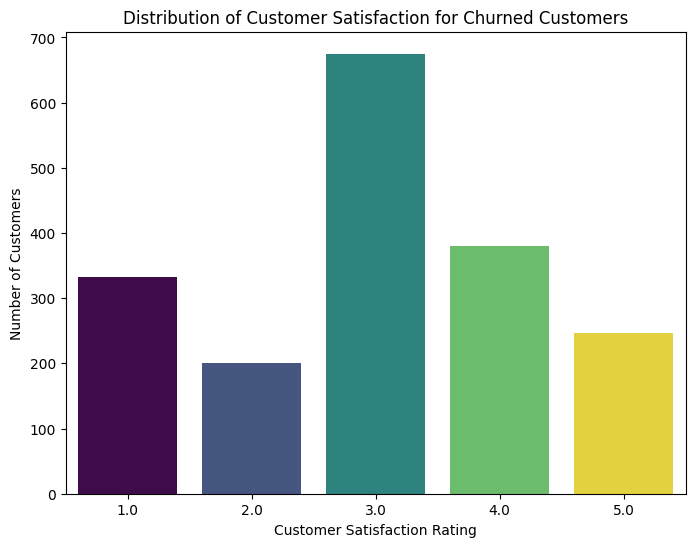

In [232]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Customer Satisfaction', hue='Customer Satisfaction', data=df, palette='viridis', legend=False)
plt.title('Distribution of Customer Satisfaction for Churned Customers')
plt.xlabel('Customer Satisfaction Rating')
plt.ylabel('Number of Customers')
plt.show()

To understand the relationship between churn category and total churn, we'll first filter the DataFrame to include only customers who have churned (`Churn Value == 1`). Then, we'll group these churned customers by their `Churn Category` and count how many fall into each category. This will show us the primary reasons why customers are churning.

In [233]:
# Filter for churned customers
churned_customers = df[df['Churn Value'] == 1]

# Group by 'Churn Category' and count the number of churned customers in each category
churn_category_counts = churned_customers['Churn Category'].value_counts().reset_index()
churn_category_counts.columns = ['Churn Category', 'Total Churn']

# Display the results
display(churn_category_counts)

,Churn Category,Total Churn
0,Competitor,841
1,Attitude,314
2,Dissatisfaction,303
3,Price,211
4,Other,200


Now, let's visualize this distribution to easily compare the impact of different churn categories.

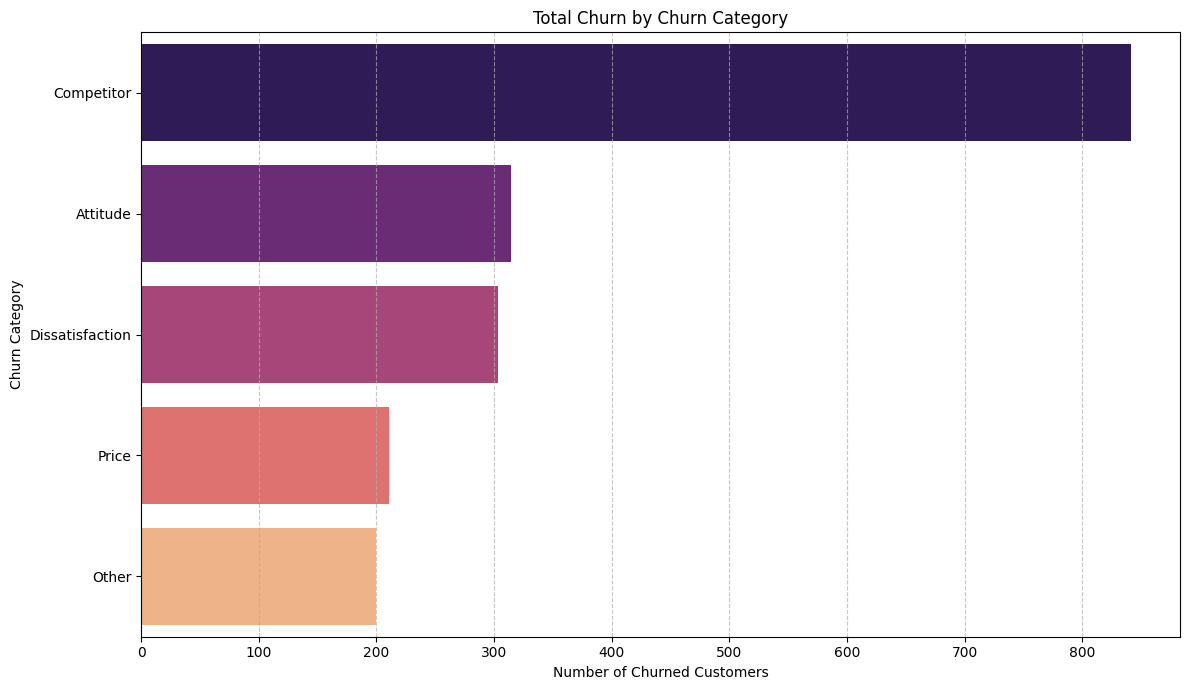

In [234]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Total Churn', y='Churn Category', hue='Churn Category', data=churn_category_counts, palette='magma', legend=False)
plt.title('Total Churn by Churn Category')
plt.xlabel('Number of Churned Customers')
plt.ylabel('Churn Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Now, let's look at the percentage distribution of 'Churn Reason' within each 'Churn Category'. This will help us understand the most common specific reasons for churn within each broader category.

In [235]:
# Ensure 'churned_customers' DataFrame is available from previous steps
# If not, recreate it:
# churned_customers = df[df['Churn Value'] == 1]

# Calculate the percentage of each 'Churn Reason' within its 'Churn Category'
churn_reason_percentages = churned_customers.groupby('Churn Category')['Churn Reason'].value_counts(normalize=True) * 100
churn_reason_percentages = churn_reason_percentages.unstack().fillna(0)

display(churn_reason_percentages)

Churn Reason,Attitude of service provider,Attitude of support person,Competitor had better devices,Competitor made better offer,Competitor offered higher download speeds,Competitor offered more data,Deceased,Don't know,Extra data charges,Lack of affordable download/upload speed,Lack of self-service on Website,Limited range of services,Long distance charges,Moved,Network reliability,Poor expertise of online support,Poor expertise of phone support,Price too high,Product dissatisfaction,Service dissatisfaction
Churn Category,,,,,,,,,,,,,,,,,,,,
Attitude,29.936306,70.063694,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Competitor,0.000000,0.000000,37.217598,36.979786,11.890606,13.91201,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Dissatisfaction,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.000000,0.000000,9.570957,12.211221,0.000000,0.0,23.762376,4.290429,3.960396,0.000000,25.412541,20.792079
Other,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,3.0,65.0,0.000000,0.000000,0.000000,0.000000,0.000000,23.0,0.000000,9.000000,0.000000,0.000000,0.000000,0.000000
Price,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.0,18.483412,14.218009,0.000000,0.000000,30.331754,0.0,0.000000,0.000000,0.000000,36.966825,0.000000,0.000000


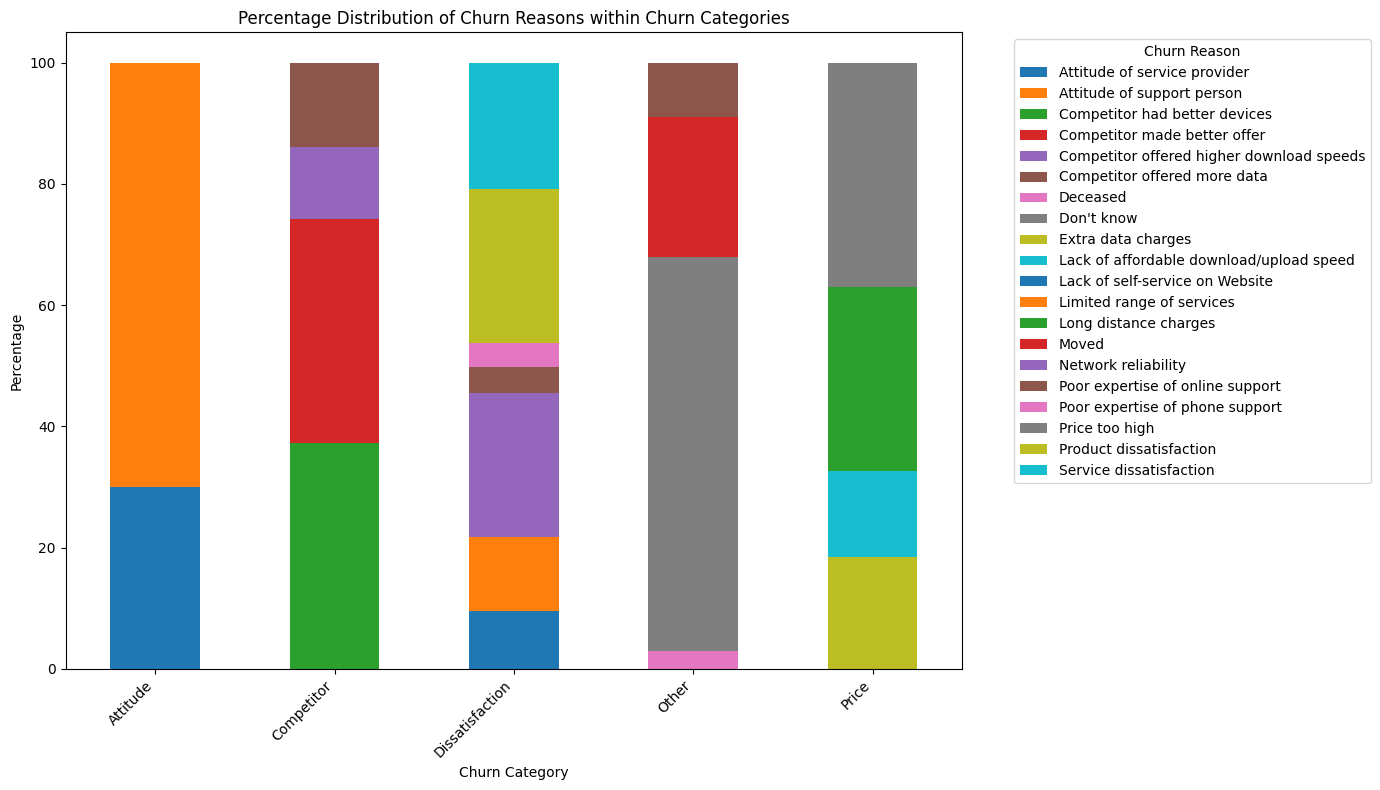

In [236]:
import matplotlib.pyplot as plt

# Plotting the stacked bar chart
ax = churn_reason_percentages.plot(kind='bar', stacked=True, figsize=(14, 8))
plt.title('Percentage Distribution of Churn Reasons within Churn Categories')
plt.xlabel('Churn Category')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Churn Reason', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Let's calculate the correlation between 'Total Customer Svc Requests' and 'Churn Value' to see if there's a relationship between the number of service requests and customer churn.

In [237]:
correlation = df['Total Customer Svc Requests'].corr(df['Churn Value'])
print(f"Correlation between 'Total Customer Svc Requests' and 'Churn Value': {correlation:.2f}")

Correlation between 'Total Customer Svc Requests' and 'Churn Value': 0.54


A box plot can visually represent the distribution of 'Total Customer Svc Requests' for each 'Churn Value', helping us understand if there's a noticeable difference between churned and non-churned customers.

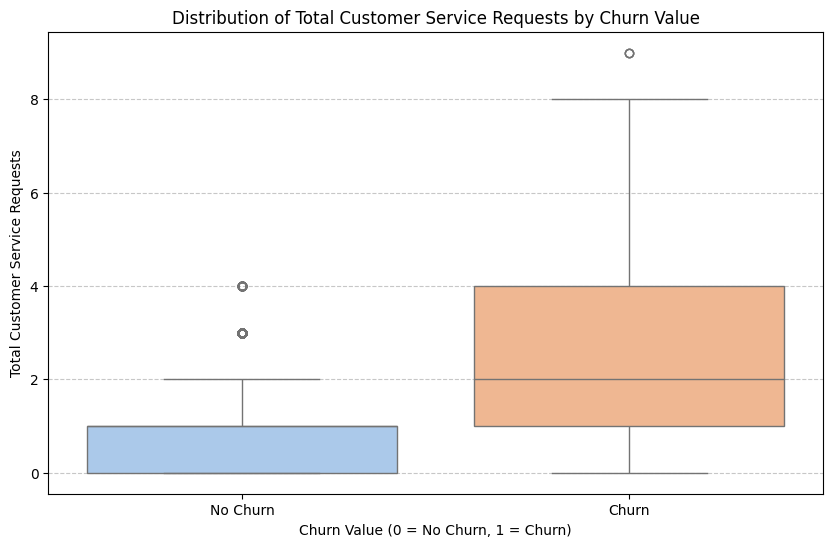

In [238]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn Value', y='Total Customer Svc Requests', data=df, palette='pastel', hue='Churn Value', legend=False)
plt.title('Distribution of Total Customer Service Requests by Churn Value')
plt.xlabel('Churn Value (0 = No Churn, 1 = Churn)')
plt.ylabel('Total Customer Service Requests')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [239]:
df.head()
features_numeric_cols = [col for col in df.columns if pd.api.types.is_numeric_dtype(df[col])]
features_non_numeric = [col for col in df.columns if pd.api.types.is_string_dtype(df[col])]
print(features_numeric_cols)
print(features_non_numeric)

scaled = StandardScaler()
df_scaled_numeric = scaled.fit_transform(df[features_numeric_cols])
pca = PCA(n_components=5)
df_pca = pca.fit_transform(df_scaled_numeric)
df_pca = pd.DataFrame(df_pca)
df_pca.head()
print(pca.explained_variance_ratio_)

['Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Regular Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Age', 'Number of Dependents', 'Zip Code', 'Latitude', 'Longitude', 'Population', 'Churn Value', 'CLTV', 'Total Customer Svc Requests', 'Product/Service Issues Reported', 'Customer Satisfaction']
['Referred a Friend', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Gender', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'City']


ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values